In [1]:
# Импорты

from pathlib import Path
from time import perf_counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.auto import tqdm
import json

d:\DataScience\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os
from dotenv import load_dotenv
from google import genai

load_dotenv()

client = genai.Client(api_key=os.getenv("GEMINI_API_KEY"))

In [3]:
import sys
sys.path.append(os.path.abspath(".."))

In [ ]:
from src.embeddings import (
    load_resnet_model,
    load_triplet_resnet_model,
    get_gemini_embedding,
    get_resnet_embedding,
    get_triplet_embedding,
)

In [5]:
# Настройка путей проекта

ROOT = Path("..")

DATA_PATH = ROOT / "data"
SPLITS_PATH = DATA_PATH / "splits"

MODELS_PATH = ROOT / "models"
RESULTS_PATH = ROOT / "results"

EMBEDDINGS_PATH = ROOT / "embeddings"

GEMINI_ORIGINAL_PATH = EMBEDDINGS_PATH / "gemini_original_train"
GEMINI_512_PATH = EMBEDDINGS_PATH / "gemini_512_train"

RESNET50_PATH = EMBEDDINGS_PATH / "resnet50_train"
RESNET50_TRIPLET_PATH = EMBEDDINGS_PATH / "resnet50_triplet_train"

RESULTS_PATH.mkdir(exist_ok=True)

In [6]:
# Определение устройства для вычислений

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

device

device(type='cuda')

In [7]:
resnet50 = load_resnet_model(
    models_path=MODELS_PATH,
    device=device,
)

triplet_resnet = load_triplet_resnet_model(
    models_path=MODELS_PATH,
    device=device,
)

d:\DataScience\My_Projects\anime_project(final_project)\src\embeddings.py:199: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(


Classification ResNet loaded.


d:\DataScience\My_Projects\anime_project(final_project)\src\embeddings.py:397: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(


Triplet ResNet loaded.


In [8]:
from src.embeddings import load_database

In [9]:
# Загрузка баз эмбеддингов

gemini_original_db = load_database(GEMINI_ORIGINAL_PATH)
gemini_512_db = load_database(GEMINI_512_PATH)

resnet50_db = load_database(RESNET50_PATH)
resnet50_triplet_db = load_database(RESNET50_TRIPLET_PATH)

print("All databases loaded.")

All databases loaded.


In [10]:
def get_gemini_original_embedding(image_path):
    return get_gemini_embedding(
        image_path=image_path,
        client=client,
        mode="original",
    )


def get_gemini_512_embedding(image_path):
    return get_gemini_embedding(
        image_path=image_path,
        client=client,
        mode="512",
    )


def get_resnet_embedding_eval(image_path):
    """
    Получает эмбеддинг изображения с помощью ResNet50 Classification.
    """
    return get_resnet_embedding(
        image_path=image_path,
        model=resnet50,
        transform=transform,
        device=device,
    )


def get_triplet_embedding_eval(image_path):
    """
    Получает эмбеддинг изображения с помощью Triplet ResNet50.
    """
    return get_triplet_embedding(
        image_path=image_path,
        model=triplet_resnet,
        transform=transform,
        device=device,
    )

In [11]:
# Проверка содержимого директории с разбиениями датасета

print(SPLITS_PATH)
print(SPLITS_PATH.exists())

for p in SPLITS_PATH.iterdir():
    print(p.name)

..\data\splits
True
test.json
train.json
val.json


In [12]:
# Загрузка тестовой выборки

with open(SPLITS_PATH / "test.json", "r", encoding="utf-8") as f:
    test_images = json.load(f)

# Проверка содержимого загруженной выборки
print(type(test_images))
print(len(test_images))
print(test_images[0])

<class 'list'>
3602
{'path': '..\\data\\processed\\Cyberpunk_Edgerunners\\_720_2147422533_00120.jpg', 'label': 'Cyberpunk_Edgerunners'}


In [13]:
# Загрузка тестовой выборки

with open(SPLITS_PATH / "test.json", "r", encoding="utf-8") as f:
    test_images = json.load(f)

# Выводим количество изображений в тестовой выборке
print(f"Test images: {len(test_images)}")

Test images: 3602


In [14]:
from src.infer import search

In [15]:
# Выбираем пример из тестовой выборки

sample = test_images[0]

# Выводим информацию о выбранном примере
print(sample)

{'path': '..\\data\\processed\\Cyberpunk_Edgerunners\\_720_2147422533_00120.jpg', 'label': 'Cyberpunk_Edgerunners'}


In [16]:
def recall_at_k(results, true_label, k):
    """
    Вычисляет метрику Recall@K.

    Args:
        results (list): Результаты поиска.
        true_label (str): Истинная метка изображения.
        k (int): Количество первых результатов для проверки.

    Returns:
        int: 1, если правильный класс найден среди первых K результатов, иначе 0.
    """
    # Получаем метки первых K найденных изображений
    predicted = [
        label
        for label, _, _ in results[:k]
    ]

    # Проверяем наличие правильного класса среди результатов
    return int(true_label in predicted)

In [17]:
def reciprocal_rank(results, true_label):
    """
    Вычисляет метрику Reciprocal Rank (RR).

    Args:
        results (list): Результаты поиска.
        true_label (str): Истинная метка изображения.

    Returns:
        float: Обратный ранг первого найденного правильного результата.
    """
    # Ищем первое совпадение с правильным классом
    for rank, (label, _, _) in enumerate(results, start=1):

        if label == true_label:
            return 1 / rank

    # Если правильный класс не найден
    return 0

In [18]:
def average_precision(results, true_label):
    """
    Вычисляет метрику Average Precision (AP).

    Args:
        results (list): Результаты поиска.
        true_label (str): Истинная метка изображения.

    Returns:
        float: Средняя точность для всех найденных релевантных результатов.
    """
    hits = 0
    precision_sum = 0

    # Проходим по результатам поиска
    for rank, (label, _, _) in enumerate(results, start=1):

        if label == true_label:
            # Учитываем найденный релевантный результат
            hits += 1
            precision_sum += hits / rank

    # Если релевантные результаты отсутствуют
    if hits == 0:
        return 0

    # Возвращаем среднюю точность
    return precision_sum / hits

In [19]:
def evaluate_model(
    get_embedding,
    database,
    test_images,
    top_k=10,
    progress_path=None,
):
    """
    Оценивает качество модели поиска изображений.

    Args:
        get_embedding (callable): Функция получения эмбеддинга.
        database (tuple): (embeddings, labels, paths).
        test_images (list): Тестовая выборка.
        top_k (int): Количество результатов поиска.
        progress_path (str | Path | None):
            Файл для сохранения прогресса.

    Returns:
        dict: Метрики качества.
    """

    embeddings, labels, paths = database

    # Начальные значения
    start_idx = 0

    recall1 = 0
    recall5 = 0
    recall10 = 0

    mrr = 0
    map_score = 0

    inference_time = 0

    # Загружаем прогресс
    if progress_path is not None:

        progress_path = Path(progress_path)

        if progress_path.exists():

            with open(progress_path, "r", encoding="utf-8") as f:
                progress = json.load(f)

            start_idx = progress["processed"]

            recall1 = progress["recall1"]
            recall5 = progress["recall5"]
            recall10 = progress["recall10"]

            mrr = progress["mrr"]
            map_score = progress["map_score"]

            inference_time = progress["inference_time"]

            print(
                f"Continue from "
                f"{start_idx}/{len(test_images)}"
            )

    # Основной цикл
    for idx in tqdm(range(start_idx, len(test_images))):

        sample = test_images[idx]

        image_path = sample["path"]
        true_label = sample["label"]

        start = perf_counter()

        query = get_embedding(image_path)

        inference_time += perf_counter() - start

        results = search(
            query,
            embeddings,
            labels,
            paths,
            top_k,
        )

        recall1 += recall_at_k(results, true_label, 1)
        recall5 += recall_at_k(results, true_label, 5)
        recall10 += recall_at_k(results, true_label, 10)

        mrr += reciprocal_rank(results, true_label)
        map_score += average_precision(results, true_label)

        # Сохраняем прогресс
        if progress_path is not None:

            with open(progress_path, "w", encoding="utf-8") as f:

                json.dump(
                    {
                        "processed": idx + 1,
                        "recall1": recall1,
                        "recall5": recall5,
                        "recall10": recall10,
                        "mrr": mrr,
                        "map_score": map_score,
                        "inference_time": inference_time,
                    },
                    f,
                    indent=4,
                )

    n = len(test_images)

    metrics = {
        "Recall@1": recall1 / n,
        "Recall@5": recall5 / n,
        "Recall@10": recall10 / n,
        "MRR": mrr / n,
        "mAP": map_score / n,
        "Avg Time (s)": inference_time / n,
    }

    # Удаляем файл прогресса после успешного завершения
    if progress_path is not None and progress_path.exists():
        progress_path.unlink()

    return metrics

In [20]:
# Преобразования изображений перед подачей в ResNet50

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [21]:
with open(SPLITS_PATH / "train.json", "r", encoding="utf-8") as f:
    train_images = json.load(f)

with open(SPLITS_PATH / "test.json", "r", encoding="utf-8") as f:
    test_images = json.load(f)

train_paths = {sample["path"] for sample in train_images}
test_paths = {sample["path"] for sample in test_images}

intersection = train_paths & test_paths

print(f"Train: {len(train_paths)}")
print(f"Test: {len(test_paths)}")
print(f"Пересечений: {len(intersection)}")
#позже удалить

Train: 16806
Test: 3602
Пересечений: 0


In [22]:
# Проверка размеров баз эмбеддингов

expected_size = len(train_images)

for name, db in {
    "Gemini Original": gemini_original_db,
    "Gemini 512": gemini_512_db,
    "ResNet50": resnet50_db,
    "ResNet50 Triplet": resnet50_triplet_db,
}.items():

    embeddings, labels, paths = db

    print(f"{name}:")
    print(f"  Embeddings: {len(embeddings)}")
    print(f"  Labels:     {len(labels)}")
    print(f"  Paths:      {len(paths)}")

    assert len(embeddings) == expected_size, (
        f"{name}: неверное число эмбеддингов!"
    )

    assert len(labels) == expected_size, (
        f"{name}: неверное число меток!"
    )

    assert len(paths) == expected_size, (
        f"{name}: неверное число путей!"
    )

print("Размеры всех баз корректны.")

Gemini Original:
  Embeddings: 16806
  Labels:     16806
  Paths:      16806
Gemini 512:
  Embeddings: 16806
  Labels:     16806
  Paths:      16806
ResNet50:
  Embeddings: 16806
  Labels:     16806
  Paths:      16806
ResNet50 Triplet:
  Embeddings: 16806
  Labels:     16806
  Paths:      16806
Размеры всех баз корректны.


In [23]:
# Проверка отсутствия тестовых изображений в поисковой базе

test_paths = {sample["path"] for sample in test_images}

for name, db in {
    "Gemini Original": gemini_original_db,
    "Gemini 512": gemini_512_db,
    "ResNet50": resnet50_db,
    "ResNet50 Triplet": resnet50_triplet_db,
}.items():

    _, _, paths = db

    overlap = sum(str(path) in test_paths for path in paths)

    print(f"{name}: пересечений = {overlap}")

    assert overlap == 0, (
        f"{name}: база содержит тестовые изображения!"
    )

print("Тестовые изображения отсутствуют во всех поисковых базах.")

Gemini Original: пересечений = 0
Gemini 512: пересечений = 0
ResNet50: пересечений = 0
ResNet50 Triplet: пересечений = 0
Тестовые изображения отсутствуют во всех поисковых базах.


In [24]:
print(paths[0])
print(paths[-1])

print(test_images[0]["path"])
print(test_images[-1]["path"])

..\data\processed\One_Punch_Man\_720_964579835_00244.jpg
..\data\processed\The_Eminence_in_Shadow\_720_1004406601_00009.jpg
..\data\processed\Cyberpunk_Edgerunners\_720_2147422533_00120.jpg
..\data\processed\Terror_in_Resonance\_720_2147392395_00217.jpg


In [25]:
test_paths = {sample["path"] for sample in test_images}

count = sum(path in test_paths for path in paths)

print(f"Совпадений: {count}")

Совпадений: 0


In [28]:
# Оценка модели Gemini Original

gemini_original_metrics = evaluate_model(
    get_embedding=get_gemini_original_embedding,
    database=gemini_original_db,
    test_images=test_images,
    progress_path="gemini_original_progress.json",
)

Continue from 16/3602


100%|██████████| 3586/3586 [2:18:11<00:00,  2.31s/it]  


In [32]:
# Оценка модели Gemini 512

gemini_512_metrics = evaluate_model(
    get_embedding=get_gemini_512_embedding,
    database=gemini_512_db,
    test_images=test_images,
    progress_path="gemini_512_progress.json",
)

100%|██████████| 3602/3602 [2:24:11<00:00,  2.40s/it]  


In [27]:
# Оценка модели ResNet50 Classification

resnet50_metrics = evaluate_model(
    get_embedding=get_resnet_embedding_eval,
    database=resnet50_db,
    test_images=test_images,
    progress_path="resnet50_progress.json",
)

Continue from 345/3602


100%|██████████| 3257/3257 [48:10<00:00,  1.13it/s]


In [33]:
# Оценка модели ResNet50 Triplet

triplet_metrics = evaluate_model(
    get_embedding=get_triplet_embedding_eval,
    database=resnet50_triplet_db,
    test_images=test_images,
    progress_path="triplet_progress.json",
)

  0%|          | 0/3602 [00:00<?, ?it/s]

100%|██████████| 3602/3602 [22:18<00:00,  2.69it/s]


In [34]:
# Сохраняем результаты оценки всех моделей

ALL_METRICS = {
    "Gemini Original": gemini_original_metrics,
    "Gemini 512": gemini_512_metrics,
    "ResNet50 Classification": resnet50_metrics,
    "ResNet50 Triplet": triplet_metrics
}

# Сохраняем метрики в JSON-файл
with open(
    RESULTS_PATH / "evaluation_metrics.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        ALL_METRICS,
        f,
        indent=4,
        ensure_ascii=False
    )

print(f"Metrics saved to: {RESULTS_PATH / 'evaluation_metrics.json'}")

Metrics saved to: ..\results\evaluation_metrics.json


In [49]:
def save_test_embeddings(
    get_embedding,
    test_images,
    output_path,
    model=None,
    transform=None,
    device=None
):
    """
    Создает и сохраняет эмбеддинги тестовой выборки.

    Args:
        get_embedding (callable): Функция получения эмбеддинга изображения.
        test_images (list): Тестовая выборка.
        output_path (Path): Путь для сохранения базы эмбеддингов.
    """
    # Создаем директорию для сохранения
    output_path.mkdir(
        parents=True,
        exist_ok=True
    )

    embeddings = []
    labels = []
    paths = []

    # Получаем эмбеддинги для всех изображений тестовой выборки
    for sample in tqdm(test_images):

        image_path = sample["path"]

        if model is None:
            embedding = get_embedding(image_path)
        else:
            embedding = get_embedding(
                image_path,
                model,
                transform,
                device
            )

        embeddings.append(embedding)

        labels.append(
            sample["label"]
        )

        paths.append(image_path)

    # Преобразуем списки в массивы NumPy
    embeddings = np.asarray(
        embeddings,
        dtype=np.float32
    )

    labels = np.asarray(labels)
    paths = np.asarray(paths)

    # Сохраняем эмбеддинги, метки и пути
    np.save(
        output_path / "embeddings.npy",
        embeddings
    )

    np.save(
        output_path / "labels.npy",
        labels
    )

    np.save(
        output_path / "paths.npy",
        paths
    )

    print(f"Saved to {output_path}")

In [36]:
# Пути для сохранения эмбеддингов тестовой выборки

TEST_GEMINI_ORIGINAL_PATH = ROOT / "embeddings" / "test_gemini_original"
TEST_GEMINI_512_PATH = ROOT / "embeddings" / "test_gemini_512"

TEST_RESNET50_PATH = ROOT / "embeddings" / "test_resnet50"
TEST_RESNET50_TRIPLET_PATH = ROOT / "embeddings" / "test_resnet50_triplet"

In [37]:
# Сохраняем эмбеддинги тестовой выборки для Gemini Original

save_test_embeddings(
    get_gemini_original_embedding,
    test_images,
    TEST_GEMINI_ORIGINAL_PATH
)

100%|██████████| 3602/3602 [1:01:43<00:00,  1.03s/it]

Saved to ..\embeddings\test_gemini_original


In [41]:
# Сохраняем эмбеддинги тестовой выборки для Gemini 512

save_test_embeddings(
    get_gemini_512_embedding,
    test_images,
    TEST_GEMINI_512_PATH
)

100%|██████████| 3602/3602 [47:16<00:00,  1.27it/s]

Saved to ..\embeddings\test_gemini_512


In [54]:
# Сохраняем эмбеддинги тестовой выборки для ResNet50 Classification

save_test_embeddings(
    get_resnet_embedding,
    test_images,
    TEST_RESNET50_PATH,
    resnet50,
    transform,
    device
)

100%|██████████| 3602/3602 [00:42<00:00, 85.35it/s]


Saved to ..\embeddings\test_resnet50


In [55]:
# Сохраняем эмбеддинги тестовой выборки для ResNet50 Triplet

save_test_embeddings(
    get_triplet_embedding,
    test_images,
    TEST_RESNET50_TRIPLET_PATH,
    triplet_resnet,
    transform,
    device
)

100%|██████████| 3602/3602 [00:42<00:00, 85.60it/s]

Saved to ..\embeddings\test_resnet50_triplet


In [56]:
# Загружаем сохраненные метрики

with open(
    RESULTS_PATH / "evaluation_metrics.json",
    "r",
    encoding="utf-8"
) as f:
    metrics = json.load(f)

# Создаем таблицу с результатами
df = pd.DataFrame(metrics).T

# Отображаем таблицу
display(df)

,Recall@1,Recall@5,Recall@10,MRR,mAP,Avg Time (s)
Gemini Original,0.899500,0.966685,0.984731,0.928905,0.883375,1.053893
Gemini 512,0.911993,0.968073,0.983343,0.936182,0.901549,0.836913
ResNet50 Classification,0.642699,0.817601,0.894225,0.718864,0.624155,0.050465
ResNet50 Triplet,0.051916,0.149084,0.193226,0.087730,0.090206,0.037981


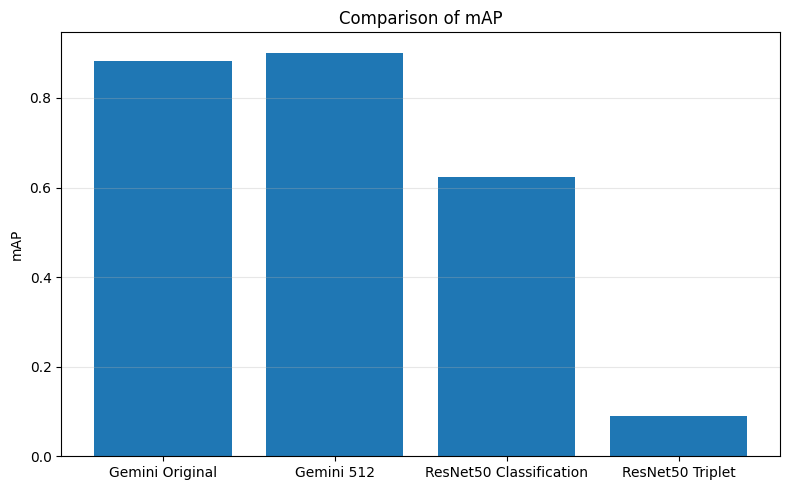

In [57]:
# Строим график сравнения значения mAP

plt.figure(figsize=(8, 5))

plt.bar(
    df.index,
    df["mAP"]
)

# Настраиваем оформление графика
plt.title("Comparison of mAP")
plt.ylabel("mAP")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

# Отображаем график
plt.show()

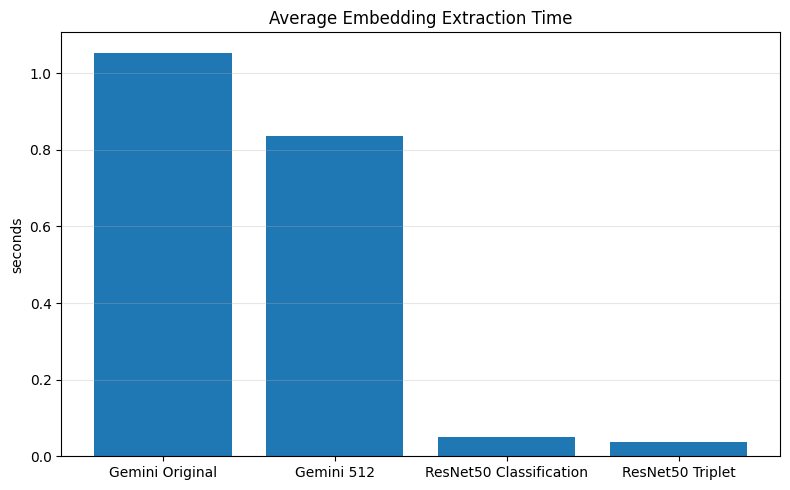

In [58]:
# Строим график сравнения среднего времени получения эмбеддингов

plt.figure(figsize=(8, 5))

plt.bar(
    df.index,
    df["Avg Time (s)"]
)

# Настраиваем оформление графика
plt.title("Average Embedding Extraction Time")
plt.ylabel("seconds")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

# Отображаем график
plt.show()

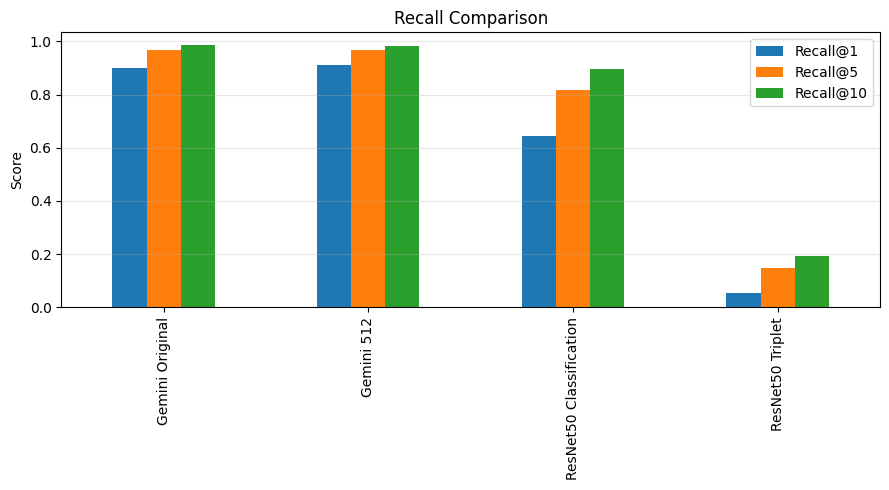

In [59]:
# Выбираем метрики Recall для сравнения моделей

recall = df[
    [
        "Recall@1",
        "Recall@5",
        "Recall@10"
    ]
]

# Строим график сравнения Recall
recall.plot(
    kind="bar",
    figsize=(9, 5)
)

# Настраиваем оформление графика
plt.title("Recall Comparison")
plt.ylabel("Score")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

# Отображаем график
plt.show()

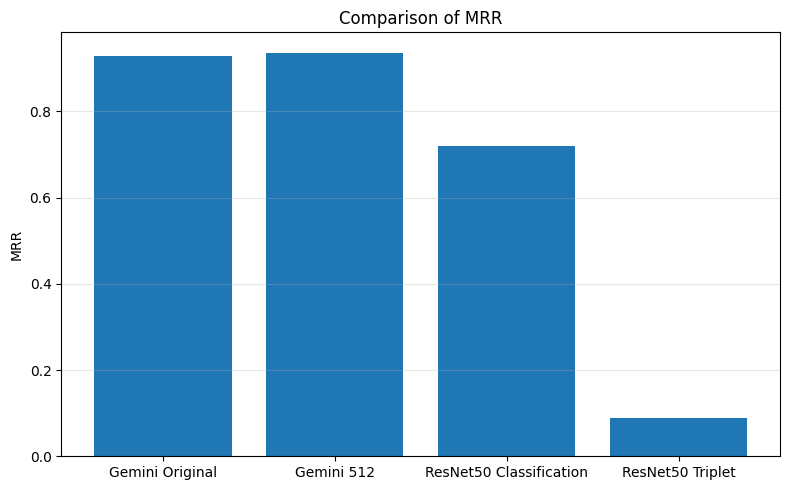

In [60]:
# Строим график сравнения значения MRR

plt.figure(figsize=(8, 5))

plt.bar(
    df.index,
    df["MRR"]
)

# Настраиваем оформление графика
plt.title("Comparison of MRR")
plt.ylabel("MRR")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

# Отображаем график
plt.show()